In [18]:
# Install required libraries
!pip install sentence-transformers faiss-cpu gradio transformers torch datasets -q
print("All libraries installed successfully!")

All libraries installed successfully!


In [19]:
# import libraries
import os
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import faiss
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import load_dataset
import gradio as gr

print("Libraries imported successfully!")

Libraries imported successfully!


In [20]:
import urllib.request
import os

if not os.path.exists('documents.py'):
    urllib.request.urlretrieve(
        "https://gist.githubusercontent.com/ishusew/d8cd9df0dae189f1d0e8f40c596c8b20/raw/fdc06e30b8bb2cb0b5c913e6e1d1bdb1b6c3f986/gistfile1.txt",
        "documents.py"
    )
    print("documents downloaded")

from documents import clinical_docs
print(f"loaded {len(clinical_docs)} clinical documents")

loaded 25 clinical documents


In [21]:
# Please Uncomment if not work above codes

# #  Clinical Q&A Documents (25)

# clinical_docs = []

# clinical_docs.append(
#     "Q: What is anxiety and what are the symptoms? "
#     "A: Anxiety is a feeling of worry, nervousness or unease that can range from mild to severe. "
#     "Common symptoms include racing heart, sweating, trouble sleeping, difficulty concentrating, "
#     "and avoiding situations that cause worry. "
#     "Types include generalised anxiety disorder GAD, panic disorder, social anxiety, and phobias. "
#     "If anxiety is affecting your daily life speak to your GP or self-refer to NHS Talking Therapies. "
#     "In a crisis call Samaritans on 116 123 free and available 24 hours."
# )

# clinical_docs.append(
#     "Q: What is depression and how is it different from just feeling sad? "
#     "A: Depression is more than feeling sad for a few days. It is a persistent low mood that affects "
#     "how you think, feel and function over weeks or months. "
#     "Symptoms include continuous low mood, loss of interest in activities, low energy, changes in sleep "
#     "or appetite, difficulty concentrating, and in severe cases thoughts of self-harm or suicide. "
#     "Depression is a medical condition not a sign of weakness. See your GP if symptoms last more than two weeks. "
#     "Effective treatments include CBT therapy, antidepressants, exercise, and social support."
# )

# clinical_docs.append(
#     "Q: What is CBT and how does it work? "
#     "A: Cognitive Behavioural Therapy CBT is the most widely used evidence-based psychological therapy. "
#     "It is based on the idea that our thoughts, feelings and behaviours are interconnected. "
#     "Negative thought patterns can maintain and worsen mental health problems. "
#     "CBT helps you identify and challenge unhelpful thoughts and change problematic behaviours. "
#     "Core techniques include thought records, behavioural activation, and exposure therapy. "
#     "CBT is effective for anxiety, depression, OCD, PTSD, and many other conditions. "
#     "Access it free through NHS Talking Therapies by self-referring online without needing a GP."
# )

# clinical_docs.append(
#     "Q: How do I access free therapy on the NHS? "
#     "A: NHS Talking Therapies previously known as IAPT offers free psychological therapies for anxiety and depression. "
#     "You do not need a GP referral. You can self-refer directly by searching NHS Talking Therapies online. "
#     "Therapies available include CBT, counselling, guided self-help, and group therapy. "
#     "Sessions are delivered by telephone, video, online, or face to face. "
#     "Waiting times vary by area. If you need urgent support contact your GP or call NHS 111. "
#     "The service is suitable for depression, anxiety, panic, phobias, OCD, PTSD, and stress."
# )

# clinical_docs.append(
#     "Q: What is mindfulness and does it actually help mental health? "
#     "A: Mindfulness means paying attention to the present moment intentionally and without judgment. "
#     "It has a strong evidence base for reducing anxiety, depression, and stress. "
#     "NICE recommends mindfulness-based cognitive therapy MBCT for preventing depression relapse. "
#     "Simple practices include focusing on your breath for five minutes, body scan meditation, "
#     "and the five senses exercise noticing what you see hear feel smell and taste. "
#     "Free resources include the NHS mindfulness course online and apps like Headspace and Calm. "
#     "Even five to ten minutes of daily practice makes a difference over time."
# )

# clinical_docs.append(
#     "Q: What are the signs of a panic attack and what should I do during one? "
#     "A: A panic attack is a sudden intense episode of fear that causes physical symptoms including "
#     "racing heart, shortness of breath, chest tightness, dizziness, shaking, and feeling of losing control. "
#     "Panic attacks are frightening but not dangerous. They usually peak within ten minutes and pass. "
#     "During a panic attack stay where you are if safe, breathe slowly and deeply, "
#     "and use the five four three two one grounding technique naming things you can see hear and feel. "
#     "Recurring panic attacks may indicate panic disorder. CBT is the most effective treatment. "
#     "See your GP if panic attacks are frequent or affecting your daily life."
# )

# clinical_docs.append(
#     "Q: What is PTSD and what causes it? "
#     "A: Post-Traumatic Stress Disorder PTSD can develop after experiencing or witnessing a traumatic event "
#     "such as assault, accident, war, disaster, or childhood abuse. "
#     "Symptoms include flashbacks and nightmares reliving the event, avoiding reminders of the trauma, "
#     "feeling emotionally numb, hypervigilance being constantly on alert, and sleep problems. "
#     "PTSD can develop immediately after trauma or months or years later. "
#     "Effective treatments include Trauma-Focused CBT and EMDR Eye Movement Desensitisation and Reprocessing "
#     "which are recommended first-line treatments by NICE. Recovery is possible with the right support."
# )

# clinical_docs.append(
#     "Q: What is OCD and how is it treated? "
#     "A: Obsessive Compulsive Disorder OCD involves unwanted intrusive thoughts called obsessions "
#     "and repetitive behaviours called compulsions carried out to reduce the anxiety they cause. "
#     "Common obsessions include fear of contamination, fear of harming others, and need for symmetry. "
#     "Common compulsions include excessive handwashing, checking locks repeatedly, and counting. "
#     "OCD is not about being overly clean or organised. It can be very distressing and time-consuming. "
#     "The most effective treatment is Exposure and Response Prevention ERP a form of CBT. "
#     "SSRIs medication can also help. See your GP for referral to specialist OCD services."
# )

# clinical_docs.append(
#     "Q: What is bipolar disorder and how is it managed? "
#     "A: Bipolar disorder involves episodes of extreme mood changes including manic episodes "
#     "of elevated mood high energy and reduced need for sleep, and depressive episodes of low mood. "
#     "During manic episodes a person may feel elated or irritable, have racing thoughts, "
#     "talk fast, behave recklessly, and have grandiose beliefs. "
#     "Bipolar disorder is a long-term condition requiring ongoing management. "
#     "Treatment includes mood stabilising medication such as lithium, psychological therapies, "
#     "and lifestyle management particularly maintaining a regular sleep routine. "
#     "See your GP urgently if you think you may be having a manic episode."
# )

# clinical_docs.append(
#     "Q: What medications are used for anxiety and depression? "
#     "A: SSRIs Selective Serotonin Reuptake Inhibitors are the most commonly prescribed medication "
#     "for both depression and anxiety. Examples include sertraline, fluoxetine, and citalopram. "
#     "They usually take four to six weeks to take full effect. "
#     "Common initial side effects include nausea and headaches which usually improve. "
#     "Do not stop SSRIs suddenly as this can cause withdrawal effects. Always discuss stopping with your GP. "
#     "Mental health medications work best when combined with therapy and lifestyle changes. "
#     "Always take medication as prescribed and discuss any concerns with your GP or psychiatrist."
# )

# clinical_docs.append(
#     "Q: How does exercise help mental health? "
#     "A: Exercise is one of the most powerful interventions for mental health with strong scientific evidence. "
#     "Regular exercise reduces symptoms of depression and anxiety as effectively as medication in some studies. "
#     "NICE recommends exercise as a first-line treatment for mild to moderate depression. "
#     "Exercise releases endorphins and serotonin, reduces stress hormones, improves sleep quality, "
#     "increases self-esteem, and provides social connection in group activities. "
#     "Adults need at least 150 minutes of moderate activity per week such as brisk walking or cycling. "
#     "Even ten minute walks help. Your GP can refer you to a local exercise programme on prescription."
# )

# clinical_docs.append(
#     "Q: How does sleep affect mental health? "
#     "A: Sleep and mental health are closely connected. Poor sleep worsens anxiety and depression "
#     "while mental health problems often cause sleep difficulties creating a difficult cycle. "
#     "Good sleep hygiene includes going to bed and waking at the same time every day, "
#     "avoiding screens for one hour before bed, keeping the bedroom cool dark and quiet, "
#     "and avoiding caffeine after 3pm and alcohol before bed. "
#     "Cognitive Behavioural Therapy for Insomnia CBT-I is more effective than sleeping pills long-term. "
#     "If sleep problems persist for more than four weeks speak to your GP."
# )

# clinical_docs.append(
#     "Q: What is burnout and how do I recover from it? "
#     "A: Burnout is a state of physical and emotional exhaustion caused by chronic workplace stress. "
#     "Signs include exhaustion that sleep does not fix, cynicism and detachment from work, "
#     "reduced performance, and physical symptoms like headaches and frequent illness. "
#     "Under the Health and Safety at Work Act employers have a duty to protect mental health. "
#     "You can ask for reasonable adjustments if mental health affects your work. "
#     "Recovery steps include speaking to your manager or HR, taking sick leave if needed, "
#     "and speaking to your GP who can provide support and referrals. "
#     "Prevention includes setting clear work-life boundaries and taking all annual leave."
# )

# clinical_docs.append(
#     "Q: How can I help someone with depression? "
#     "A: Supporting someone with depression requires patience, empathy, and practical help. "
#     "Listen without judgment and avoid telling them to cheer up or snap out of it. "
#     "Ask them directly how they are feeling and take what they say seriously. "
#     "Help with practical tasks like shopping or cooking if they are struggling to manage. "
#     "Encourage them to seek professional help and offer to go with them to a GP appointment. "
#     "Stay connected with regular contact even if they withdraw. "
#     "Look after your own wellbeing too as supporting someone with depression can be emotionally draining. "
#     "If you are worried they may harm themselves call 999 or Samaritans on 116 123."
# )

# clinical_docs.append(
#     "Q: What is self-harm and where can I get help? "
#     "A: Self-harm means deliberately hurting yourself as a way of coping with emotional pain or distress. "
#     "It is more common than many people realise particularly among young people. "
#     "Self-harm is not attention-seeking. It is usually a way of expressing pain that feels impossible to put into words. "
#     "If you self-harm you deserve help and support not judgment. "
#     "Speak to your GP who can refer you to appropriate services. "
#     "Crisis support is available from Samaritans on 116 123 or by texting SHOUT to 85258. "
#     "MIND helpline is available on 0300 123 3393. Recovery is possible with the right support."
# )

# clinical_docs.append(
#     "Q: What are the mental health crisis helpline numbers in the UK? "
#     "A: Samaritans: call 116 123 free and available 24 hours seven days a week, confidential emotional support. "
#     "Shout Crisis Text Line: text SHOUT to 85258 free and available 24 hours. "
#     "CALM Campaign Against Living Miserably: 0800 58 58 58 available 5pm to midnight. "
#     "PAPYRUS for young people at risk of suicide: 0800 068 4141. "
#     "Mind Infoline: 0300 123 3393 Monday to Friday 9am to 6pm. "
#     "NHS 111: call 111 and select the mental health option available 24 hours. "
#     "In immediate danger always call 999 or go to your nearest Accident and Emergency department."
# )

# clinical_docs.append(
#     "Q: What is social anxiety and how is it treated? "
#     "A: Social anxiety is an intense and persistent fear of social situations where you may be "
#     "judged, embarrassed, or humiliated by others. It is more than just shyness. "
#     "Symptoms include fear of speaking in public, avoiding social situations, intense self-consciousness, "
#     "blushing, sweating, and shaking in social contexts. "
#     "Social anxiety can significantly affect work, relationships, and daily functioning. "
#     "The most effective treatment is CBT specifically exposure therapy gradually facing feared social situations. "
#     "Medication such as SSRIs can also help. Self-refer to NHS Talking Therapies for free CBT."
# )

# clinical_docs.append(
#     "Q: How does alcohol affect mental health? "
#     "A: Alcohol is a depressant that affects brain chemistry and mental health significantly. "
#     "Many people drink to cope with stress or low mood but alcohol makes these problems worse over time. "
#     "Short-term effects include low mood, increased anxiety, poor sleep, and impulsive decisions. "
#     "Long-term heavy drinking significantly increases risk of depression, anxiety disorders, and psychosis. "
#     "Recommended limits are no more than 14 units per week spread over several days with alcohol-free days. "
#     "If you drink to manage mental health symptoms this is a warning sign worth discussing with your GP. "
#     "Drinkline is available on 0300 123 1110 for support with alcohol concerns."
# )

# clinical_docs.append(
#     "Q: What is grief and how do I cope with loss? "
#     "A: Grief is a natural response to loss including the death of a loved one, relationship breakdown, "
#     "job loss, or diagnosis of serious illness. There is no right or wrong way to grieve. "
#     "You may experience shock, sadness, anger, guilt, anxiety, or even relief at different times. "
#     "Most people find grief becomes less intense over time with support and self-care. "
#     "Complicated grief that severely impacts daily life after several months may benefit from professional support. "
#     "Cruse Bereavement Support is available on 0808 808 1677 free of charge. "
#     "Your GP can refer you to bereavement counselling. Talking to others who have experienced similar loss can help."
# )

# clinical_docs.append(
#     "Q: What is the difference between a psychiatrist and a psychologist? "
#     "A: A psychiatrist is a medical doctor who specialises in mental health. "
#     "They can diagnose mental health conditions, prescribe medication, and provide therapy. "
#     "They are involved in more complex or severe mental health cases. "
#     "A psychologist has a doctorate in psychology but is not a medical doctor. "
#     "They cannot prescribe medication but provide assessment and psychological therapies like CBT. "
#     "A counsellor provides talking support and guidance for emotional difficulties. "
#     "Your GP is usually your first point of contact who can then refer you to the appropriate professional "
#     "depending on the nature and severity of your mental health concerns."
# )

# clinical_docs.append(
#     "Q: What are eating disorders and where can I get help? "
#     "A: Eating disorders are serious mental health conditions affecting how people relate to food and their body. "
#     "Types include anorexia nervosa restricting food severely, bulimia nervosa cycles of bingeing and purging, "
#     "and binge eating disorder. "
#     "Warning signs include preoccupation with weight and calories, avoiding eating with others, "
#     "and significant weight changes. "
#     "Eating disorders have the highest mortality rate of any mental health condition. "
#     "Early treatment significantly improves outcomes. "
#     "Beat helpline is available on 0808 801 0677. Your GP can refer you to specialist eating disorder services. "
#     "NHS Talking Therapies offers CBT for some eating disorders."
# )

# clinical_docs.append(
#     "Q: How do I manage stress effectively? "
#     "A: Stress is the body's response to pressure and while some stress is normal, chronic stress harms health. "
#     "Effective stress management strategies include regular physical exercise which reduces stress hormones, "
#     "good sleep routine, time management and prioritising tasks, "
#     "talking to someone you trust, and reducing alcohol and caffeine. "
#     "Mindfulness-based stress reduction MBSR has strong evidence for managing chronic stress. "
#     "Setting clear boundaries at work and in personal life is essential. "
#     "If stress is unmanageable speak to your GP or self-refer to NHS Talking Therapies. "
#     "Identifying and addressing the root causes of stress is more effective than managing symptoms alone."
# )

# clinical_docs.append(
#     "Q: What is Mindfulness-Based Cognitive Therapy MBCT? "
#     "A: Mindfulness-Based Cognitive Therapy MBCT combines mindfulness practices with cognitive therapy techniques. "
#     "It was specifically developed to prevent relapse in people who have experienced repeated episodes of depression. "
#     "NICE recommends MBCT for people who have had three or more episodes of depression. "
#     "The programme typically runs over eight weeks in a group format. "
#     "It teaches participants to become aware of and relate differently to their thoughts, feelings, and body sensations. "
#     "Rather than trying to change negative thoughts MBCT teaches people to observe them without judgment. "
#     "Ask your GP for a referral or search for MBCT programmes through NHS Talking Therapies."
# )

# clinical_docs.append(
#     "Q: What regulations govern AI systems used in mental health support? "
#     "A: The EU AI Act 2024 classifies AI systems used in mental health support as high-risk applications. "
#     "This requires mandatory human oversight, rigorous bias testing, transparent documentation, "
#     "and clear disclosure to users that they are interacting with an AI system. "
#     "Under GDPR mental health data is classified as special category data under Article 9 "
#     "requiring explicit user consent, strict security measures, and the right to erasure. "
#     "Organisations deploying mental health AI must conduct regular safety audits "
#     "and ensure human professional involvement for serious clinical cases. "
#     "AI systems should extend access to support not replace human clinical judgment and empathy."
# )

# clinical_docs.append(
#     "Q: What digital tools and apps can help with mental health? "
#     "A: Several NHS recommended digital tools can support mental health alongside professional care. "
#     "Headspace and Calm offer guided mindfulness and sleep meditations with free trials available. "
#     "SilverCloud is an online CBT programme available through NHS Talking Therapies. "
#     "Daylio is a mood tracking app that helps identify patterns in mood and behaviour. "
#     "Every Mind Matters on the NHS website offers free personalised mental health advice. "
#     "Limitations of digital tools include being unsuitable for severe mental health conditions "
#     "and inability to replace human connection or professional assessment. "
#     "Always check if an app is NHS approved. In a crisis do not rely on an app but contact 999 or Samaritans."
# )

# print(f"Clinical documents loaded: {len(clinical_docs)}")

In [22]:
# Load HuggingFace Dataset & Combine
# Load mental health therapy dataset from HuggingFace
dataset = load_dataset("fadodr/mental_health_therapy", split="train")

counselling_docs = []
for item in dataset.select(range(50)):
    question = item['input']
    answer = item['output']
    counselling_docs.append(f"Q: {question} A: {answer}")

print(f"Loaded {len(counselling_docs)} counselling conversations")

# Combine both data sources
docs = counselling_docs + clinical_docs

print(f"Counselling conversations: {len(counselling_docs)}")
print(f"Clinical documents: {len(clinical_docs)}")
print(f"Total knowledge base: {len(docs)} documents")

Loaded 50 counselling conversations
Counselling conversations: 50
Clinical documents: 25
Total knowledge base: 75 documents


In [23]:
# Chunking, Embedding & FAISS Index
# Split documents into smaller chunks
def make_chunks(text, size=150, overlap=25):
    words = text.split()
    chunks = []
    i = 0
    while i < len(words):
        chunks.append(' '.join(words[i:i+size]))
        if i + size >= len(words):
            break
        i += size - overlap
    return chunks

# Create chunks from all documents
chunks = []
for doc in docs:
    chunks.extend(make_chunks(doc))

print(f"Total chunks created: {len(chunks)}")

# Load embedding model
print("Loading embedding model...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

# Convert all chunks to vectors
print("Converting chunks to vectors...")
embeddings = embedder.encode(chunks, show_progress_bar=True)

# Build FAISS index
dim = embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(embeddings.astype('float32'))

print(f"FAISS index ready: {index.ntotal} vectors stored")

Total chunks created: 225
Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Converting chunks to vectors...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

FAISS index ready: 225 vectors stored


In [24]:
# Load Language Model
# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load Flan-T5-large from HuggingFace
print("Loading language model...")
tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-large')
model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-large').to(device)
model.eval()

print(f"Model loaded on: {device}")

Loading language model...


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Model loaded on: cuda


In [25]:
# Safeguards & Chat Functions
import time

# Crisis detection words
crisis_words = [
    # Direct self-harm/suicide
    'kill myself', 'want to die', 'end my life', 'end it all',
    'suicide', 'suicidal', 'self-harm', 'self harm',
    'how to die', 'how to kill myself', 'how to commit suicide',
    'i want to die', 'i want to kill myself', 'i wish i was dead',
    'better off dead', 'no reason to live', 'nothing to live for',
    'should i kill myself', 'should i die',

    # Methods
    'suicide method', 'how to overdose', 'how to harm myself',
    'cut myself', 'hurt myself', 'harm myself',

    # Single words (catch-all)
    'kill', 'die', 'dying', 'death', 'overdose',
]

# Crisis response
crisis_response = (
    'I am concerned about what you have shared. '
    'Please reach out for immediate support.\n\n'
    'Sri Lanka:\n'
    'Sumithrayo: +94 11 2692909 (24 hours)\n'
    'CCCline: 1333 (free, 24 hours)\n\n'
    'International:\n'
    'Befrienders Worldwide: www.befrienders.org\n'
    'Crisis Text Line: Text HOME to 741741 (US/UK)\n'
    'International Association for Suicide Prevention: www.iasp.info\n\n'
    'You do not have to face this alone. '
    'Please contact one of these services now.'
)

# Topic filter - only answer psychological healthcare questions
health_words = [
    'anxiety', 'depression', 'stress', 'mental health',
    'therapy', 'counselling', 'panic', 'ptsd', 'trauma',
    'ocd', 'bipolar', 'sleep', 'mindfulness', 'cbt',
    'medication', 'antidepressant', 'burnout', 'grief',
    'eating disorder', 'self harm', 'suicidal', 'wellbeing',
    'feeling', 'mood', 'emotion', 'worried', 'struggling',
    'help', 'support', 'nhs', 'therapist', 'psychiatrist',
]

def is_crisis(question):
    return any(word in question.lower() for word in crisis_words)

def is_relevant(question):
    return any(word in question.lower() for word in health_words)

def retrieve_context(question, top_k=6):
    q_vector = embedder.encode([question]).astype('float32')
    distances, indices = index.search(q_vector, top_k * 2)

    clinical_chunks = []
    counselling_chunks = []

    for idx in indices[0]:
        chunk = chunks[idx]
        if any(kw in chunk.lower() for kw in ['symptom', 'treatment', 'medication', 'NHS', 'GP', 'diagnosis']):
            clinical_chunks.append((chunk, distances[0][list(indices[0]).index(idx)]))
        else:
            counselling_chunks.append((chunk, distances[0][list(indices[0]).index(idx)]))

    clinical_chunks.sort(key=lambda x: x[1])
    counselling_chunks.sort(key=lambda x: x[1])

    final_chunks = [c[0] for c in clinical_chunks[:3]] + [c[0] for c in counselling_chunks[:3]]
    final_distances = [c[1] for c in clinical_chunks[:3]] + [c[1] for c in counselling_chunks[:3]]

    return final_chunks[:top_k], final_distances[:top_k]

def generate_answer(question, context_chunks):
    context = ' '.join(context_chunks)

    if len(context) > 1000:
        context = context[:1000] + "..."

    prompt = f"""You are a mental health assistant. Answer the question using ONLY the information below.

Information: {context}

Question: {question}

Answer (use only the information above, be specific and helpful):"""

    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=512
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.3,
            do_sample=True,
            no_repeat_ngram_size=3
        )

    answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # If answer is too short, use the first clinical chunk directly
    if len(answer.split()) < 10 and context_chunks:
        chunk = context_chunks[0]
        if "A:" in chunk:
            answer = chunk.split("A:")[-1].strip()
        else:
            answer = chunk

    return answer

def chat(question):
    t0 = time.time()
    question = question.strip()

    # Safeguard 1 - Empty input
    if not question:
        return 'Please type a question.'

    # Safeguard 2 - Crisis detection
    if is_crisis(question):
        return crisis_response

    # Safeguard 3 - Topic filter
    if not is_relevant(question):
        return (
            'This chatbot specialises in psychological healthcare support. '
            'Please ask about mental health topics such as anxiety, depression, '
            'stress, therapy options, coping strategies, or mental health services.'
        )

    # Retrieve relevant chunks
    context, distances = retrieve_context(question)

    # Safeguard 4 - Confidence threshold
    if distances[0] > 1.5:
        return (
            'I do not have specific information on that topic. '
            'Please contact your GP or call NHS 111 for advice.'
        )

    # Generate answer
    answer = generate_answer(question, context)
    elapsed = round(time.time() - t0, 1)

    return (
        f'{answer}\n\n'
        f'This is general information only and not a substitute for '
        f'professional medical advice. If you are struggling please '
        f'speak to your GP or a qualified mental health professional.\n'
        f'Response time: {elapsed}s'
    )

# Test the chatbot
print("Testing RAG system...")
print(chat("what are the symptoms of anxiety?"))

Testing RAG system...
a feeling of worry, nervousness or unease that can range from mild to severe

This is general information only and not a substitute for professional medical advice. If you are struggling please speak to your GP or a qualified mental health professional.
Response time: 2.1s


In [26]:
# Testing
print("Testing crisis detection:")
test_crisis = [
    "how to die",
    "kill",
    "kill myself",
    "i want to die",
    "suicide"
]

for t in test_crisis:
    result = chat(t)
    print(f"Input: '{t}'")
    print(f"Output: {result[:200]}...")
    print("-" * 50)

print("Testing questions:")
def debug_retrieval(question):
    context, distances = retrieve_context(question)
    print(f"\n=== RETRIEVED CHUNKS for '{question}' ===")
    for i, (chunk, dist) in enumerate(zip(context, distances)):
        print(f"\nChunk {i+1} (distance: {dist:.4f}):")
        print(chunk[:300] + "...")
    print("=" * 50)

debug_retrieval("what are the symptoms of anxiety?")

Testing crisis detection:
Input: 'how to die'
Output: I am concerned about what you have shared. Please reach out for immediate support.

Sri Lanka:
Sumithrayo: +94 11 2692909 (24 hours)
CCCline: 1333 (free, 24 hours)

International:
Befrienders Worldwid...
--------------------------------------------------
Input: 'kill'
Output: I am concerned about what you have shared. Please reach out for immediate support.

Sri Lanka:
Sumithrayo: +94 11 2692909 (24 hours)
CCCline: 1333 (free, 24 hours)

International:
Befrienders Worldwid...
--------------------------------------------------
Input: 'kill myself'
Output: I am concerned about what you have shared. Please reach out for immediate support.

Sri Lanka:
Sumithrayo: +94 11 2692909 (24 hours)
CCCline: 1333 (free, 24 hours)

International:
Befrienders Worldwid...
--------------------------------------------------
Input: 'i want to die'
Output: I am concerned about what you have shared. Please reach out for immediate support.

Sri Lanka:
Sumi

In [27]:
# Evaluation
print("EVALUATION — CIS142-6 Part B")

test_cases = [
    ("what are symptoms of anxiety", ["worry", "nervous", "sleep", "heart", "anxiety"]),
    ("how do I manage a panic attack", ["breath", "calm", "panic", "ground", "pass"]),
    ("what is CBT therapy", ["thought", "behav", "cognitive", "therapy", "cbt"]),
    ("how does exercise help depression", ["exercise", "mood", "depress", "activ", "endorphin"]),
    ("how do I access NHS therapy", ["nhs", "gp", "refer", "talk", "therap"]),
    ("what are signs of burnout", ["exhaust", "stress", "work", "tired", "burn"]),
    ("what medication is used for depression", ["ssri", "medic", "antidepress", "fluoxet", "sertral"]),
    ("how can I help someone with depression", ["listen", "support", "help", "encour", "gp"]),
    ("what is mindfulness", ["present", "moment", "mind", "breath", "aware"]),
    ("what are crisis helplines in the UK", ["116", "samar", "shout", "85258", "crisis"]),
]

passed = 0
latencies = []

for question, keywords in test_cases:
    t = time.time()
    answer = chat(question).lower()
    elapsed = time.time() - t
    latencies.append(elapsed)
    ok = any(kw in answer for kw in keywords)
    if ok:
        passed += 1
    print(f"{'PASS' if ok else 'FAIL'} | {question[:45]} ({elapsed:.1f}s)")

print(f"\nAccuracy: {passed}/{len(test_cases)} ({passed/len(test_cases)*100:.0f}%)")
print(f"Avg latency: {sum(latencies)/len(latencies):.1f}s")
print(f"\nSystem info:")
print(f"  Documents: {len(docs)}")
print(f"  Chunks: {len(chunks)}")
print(f"  Embedding model: all-MiniLM-L6-v2")
print(f"  LLM: google/flan-t5-large")
print(f"  Vector DB: FAISS")
print(f"  Safeguards: 4")
print(f"  Cost: free on Google Colab")

EVALUATION — CIS142-6 Part B
PASS | what are symptoms of anxiety (1.0s)
PASS | how do I manage a panic attack (1.0s)
PASS | what is CBT therapy (4.6s)
PASS | how does exercise help depression (1.5s)
PASS | how do I access NHS therapy (0.6s)
PASS | what are signs of burnout (0.8s)
PASS | what medication is used for depression (6.3s)
PASS | how can I help someone with depression (0.5s)
PASS | what is mindfulness (1.8s)
FAIL | what are crisis helplines in the UK (0.6s)

Accuracy: 9/10 (90%)
Avg latency: 1.9s

System info:
  Documents: 75
  Chunks: 225
  Embedding model: all-MiniLM-L6-v2
  LLM: google/flan-t5-large
  Vector DB: FAISS
  Safeguards: 4
  Cost: free on Google Colab


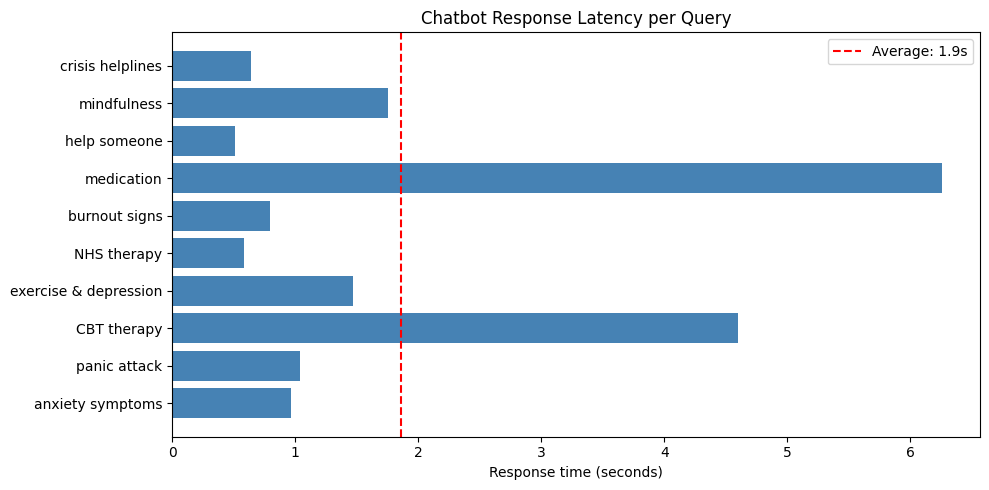

Chart saved


In [28]:
#
import matplotlib.pyplot as plt

question_labels = [
    "anxiety symptoms",
    "panic attack",
    "CBT therapy",
    "exercise & depression",
    "NHS therapy",
    "burnout signs",
    "medication",
    "help someone",
    "mindfulness",
    "crisis helplines"
]

plt.figure(figsize=(10, 5))
plt.barh(question_labels, latencies, color='steelblue')
plt.axvline(
    sum(latencies)/len(latencies),
    color='red',
    linestyle='--',
    label=f'Average: {sum(latencies)/len(latencies):.1f}s'
)
plt.xlabel('Response time (seconds)')
plt.title('Chatbot Response Latency per Query')
plt.legend()
plt.tight_layout()
plt.savefig('latency_chart.png')
plt.show()
print("Chart saved")

In [29]:
import gradio as gr

custom_css = """
.gradio-container {
    max-width: 900px !important;
    margin: auto !important;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif !important;
}

.main-header {
    text-align: center;
    padding: 20px 0 10px 0;
}
.main-header h1 {
    font-size: 2.5rem;
    font-weight: 700;
    background: linear-gradient(135deg, #2C3E8C, #4A90D9);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    margin-bottom: 5px;
}
.main-header p {
    color: #666;
    font-size: 1.1rem;
    -webkit-text-fill-color: #666;
}

.chat-container {
    border-radius: 16px;
    border: 1px solid #e0e0e0;
    padding: 5px;
    background: white;
    box-shadow: 0 4px 15px rgba(0,0,0,0.08);
}

.input-container {
    border-radius: 12px;
    border: 2px solid #e0e0e0;
    padding: 8px 15px;
    background: white;
    transition: border-color 0.3s ease;
}
.input-container:focus-within {
    border-color: #4A90D9;
    box-shadow: 0 0 0 3px rgba(74, 144, 217, 0.15);
}
.input-container textarea {
    border: none !important;
    outline: none !important;
    box-shadow: none !important;
    font-size: 1rem !important;
}

.primary-btn {
    background: linear-gradient(135deg, #2C3E8C, #4A90D9) !important;
    color: white !important;
    border: none !important;
    border-radius: 12px !important;
    padding: 12px 30px !important;
    font-weight: 600 !important;
    transition: transform 0.2s, box-shadow 0.2s !important;
    cursor: pointer !important;
}
.primary-btn:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 6px 20px rgba(74, 144, 217, 0.4) !important;
}
.clear-btn {
    background: #e53e3e !important;
    color: white !important;
    border: none !important;
    border-radius: 12px !important;
    padding: 12px 20px !important;
    font-weight: 600 !important;
    transition: transform 0.2s !important;
}
.clear-btn:hover {
    transform: scale(1.03) !important;
}

.disclaimer-box {
    background: #fffbeb !important;
    border-left: 5px solid #f6ad55 !important;
    border-radius: 10px !important;
    padding: 12px 18px !important;
    margin: 10px 0 !important;
    font-size: 0.9rem !important;
    color: #744210 !important;
}
.crisis-box {
    background: #fff5f5 !important;
    border-left: 5px solid #e53e3e !important;
    border-radius: 10px !important;
    padding: 12px 18px !important;
    margin: 10px 0 !important;
    font-size: 0.9rem !important;
    color: #742a2a !important;
}

.examples-section {
    background: #f7fafc !important;
    border-radius: 12px !important;
    padding: 15px !important;
    margin-top: 10px !important;
}
.examples-section .gr-button {
    background: white !important;
    border: 1px solid #e2e8f0 !important;
    border-radius: 20px !important;
    padding: 6px 16px !important;
    font-size: 0.85rem !important;
    transition: all 0.2s !important;
}
.examples-section .gr-button:hover {
    background: #ebf4ff !important;
    border-color: #4A90D9 !important;
}

.footer {
    text-align: center;
    padding: 20px 0 10px 0;
    color: #a0aec0;
    font-size: 0.8rem;
    border-top: 1px solid #e2e8f0;
    margin-top: 15px;
}

.sidebar-section {
    background: #f7fafc;
    border-radius: 12px;
    padding: 15px;
    margin-bottom: 10px;
}
.sidebar-section h4 {
    color: #2d3748;
    margin-bottom: 8px;
}
.sidebar-section .helpline {
    color: #2C3E8C;
    font-weight: 600;
}
"""

def respond(message, history):
    reply = chat(message)
    history.append({"role": "user", "content": message})
    history.append({"role": "assistant", "content": reply})
    return history, ""

with gr.Blocks() as app:

    gr.HTML("""
    <div class="main-header">
        <h1>Psychological Healthcare Support</h1>
        <p>Safe, supportive, and grounded in trusted mental health information</p>
    </div>
    """)

    gr.HTML("""
    <div class="disclaimer-box">
        <strong>Important:</strong> This chatbot provides general psychological health information only.
        It is <strong>NOT</strong> a substitute for professional medical advice, diagnosis, or treatment.
        If you are in crisis, please use the helplines below.
    </div>
    """)

    gr.HTML("""
    <div class="crisis-box">
        <strong>In Crisis? Reach out now:</strong><br>
        <strong>Sri Lanka:</strong> Sumithrayo +94 11 2692909 (24h) | CCCline 1333 (free)<br>
        <strong>UK:</strong> Samaritans 116 123 (24h) | SHOUT text 85258
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1, min_width=180):
            gr.HTML("""
            <div class="sidebar-section">
                <h4>Quick Resources</h4>
                <p><span class="helpline">Samaritans:</span> 116 123</p>
                <p><span class="helpline">SHOUT:</span> Text 85258</p>
                <p><span class="helpline">NHS 111:</span> Option 2</p>
                <hr style="margin: 10px 0;">
                <p><span class="helpline">Sumithrayo:</span> +94 11 2692909</p>
                <p><span class="helpline">CCCline:</span> 1333</p>
            </div>

            <div class="sidebar-section">
                <h4>Topics I Can Help With</h4>
                <ul style="list-style: none; padding: 0; font-size: 0.9rem;">
                    <li>Anxiety and Worry</li>
                    <li>Depression and Low Mood</li>
                    <li>Stress and Burnout</li>
                    <li>CBT and Therapy</li>
                    <li>Sleep and Wellbeing</li>
                    <li>Panic and Trauma</li>
                    <li>OCD and Bipolar</li>
                    <li>Mental Health Helplines</li>
                </ul>
            </div>
            """)

            clear_btn = gr.Button("Clear Chat", elem_classes="clear-btn", size="sm")

        with gr.Column(scale=3):
            chatbot = gr.Chatbot(height=450, elem_classes="chat-container")

            with gr.Row():
                msg = gr.Textbox(
                    placeholder="e.g. what are the symptoms of anxiety?",
                    label="Your question",
                    scale=4,
                    elem_classes="input-container"
                )
                send_btn = gr.Button("Send", elem_classes="primary-btn", scale=1)

    gr.HTML("""
    <div class="examples-section">
        <p style="color: #4a5568; font-weight: 500; margin-bottom: 8px;">
            Try these example questions:
        </p>
    </div>
    """)

    gr.Examples(
        examples=[
            ["what are the symptoms of anxiety?"],
            ["how can I manage stress?"],
            ["what is CBT therapy?"],
            ["how do I access free NHS therapy?"],
            ["what should I do during a panic attack?"],
            ["how does exercise help depression?"],
            ["what are signs of burnout?"],
            ["how can I help someone with depression?"],
            ["what is mindfulness?"],
            ["what are mental health helplines?"],
        ],
        inputs=msg,
        label=""
    )

    gr.HTML("""
    <div class="footer">
        Made for psychological wellbeing support | MSc NLP Project 2026
    </div>
    """)

    send_btn.click(respond, [msg, chatbot], [chatbot, msg])
    msg.submit(respond, [msg, chatbot], [chatbot, msg])
    clear_btn.click(lambda: ([], ""), outputs=[chatbot, msg])

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://16c2df75ed857a3675.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
